# B19 — Bell Inequalities and CHSH

**Track B — the SDK.** This is the one notebook in the repo where the output is
not a demonstration of a technique but a **claim about the world**.

---

## The one-sentence version

Take two entangled qubits, measure each along an angle you get to choose, and
combine four such correlations into a single number $S$. **Any** theory in which
the particles carried their answers with them — a *local hidden-variable* theory,
which is to say, the way everything else in your experience works — is forced by
arithmetic alone into $|S| \le 2$. Quantum mechanics predicts $S = 2\sqrt2
\approx 2.828$, and that is what this notebook measures.

There is no interpretation to argue about in the bound itself. $|S| \le 2$ is not
a result of quantum theory; it is a result of *classical* assumptions, provable in
three lines of algebra with no physics in it at all. So a measured $S > 2$ does
not say "quantum mechanics is weird". It says a whole *class* of explanations is
dead, including every explanation of the form "the qubits agreed in advance".

## Why you should be suspicious of this notebook

Straight up, before anything else: **a simulator cannot rule out local realism.**
Every number below is produced by a classical computer running a program that was
written to reproduce quantum predictions. Of course it "violates" the inequality —
it was told to.

What this notebook can honestly do is three things, and it does all three:

1. **Make the bound concrete.** We derive $|S| \le 2$ from scratch and then throw
   twenty thousand actual local hidden-variable models at it and watch every one
   of them bounce off the wall.
2. **Make the quantum value concrete.** We compute $S(\theta)$ with real Qiskit
   observables and watch the curve cross a line that classical physics says has no
   points above it.
3. **Make the fragility concrete.** We turn on depolarizing noise and watch the
   violation die — which is exactly why the real experiment took fifty years.

The honest-limits section at the end says plainly what a real loophole-free Bell
test needed and why 2015 was the year it happened. Read it; it is the reason this
figure matters.

## What Track A already gave us

| Track A | here |
|---|---|
| A04: measurement is a *choice of basis*, then a random outcome | the "angle" each side picks |
| A04: $\sigma = \sqrt{p(1-p)/N}$, error falls as $1/\sqrt N$ | the error bar on $S$ |
| A06: little-endian two-qubit operators, `np.kron` in reverse | `SparsePauliOp("ZX")` |
| A06: entanglement is created by two-qubit gates and nothing else | the Bell state we measure |
| A12: the depolarizing channel as a shrinking Bloch ball | the noise that kills the violation |

The checkpoint at the bottom rebuilds $S$ in raw NumPy the A06 way and asserts it
against Qiskit's `EstimatorV2` output.

In [1]:
from qviz import backends, grid, style

import itertools

import matplotlib.pyplot as plt
import numpy as np
import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import ClassicalRegister, QuantumRegister
from qiskit.quantum_info import DensityMatrix, SparsePauliOp, Statevector
from qiskit_aer.noise import NoiseModel, depolarizing_error

style.use()

SEED = backends.seed_for("B19")
rng = np.random.default_rng(SEED)

TSIRELSON = 2 * np.sqrt(2)
CLASSICAL = 2.0

print("qiskit", qiskit.__version__, " seed", SEED)
print(f"classical bound {CLASSICAL}   Tsirelson bound {TSIRELSON:.6f}")

qiskit 2.5.1  seed 20260823
classical bound 2.0   Tsirelson bound 2.828427


---

## Part 1 — the experiment, stated precisely

Two qubits in the Bell state

$$|\Phi^+\rangle = \tfrac{1}{\sqrt2}\big(|00\rangle + |11\rangle\big),$$

which A06 built by hand and B18 dissected. Alice holds qubit 0, Bob holds qubit 1,
and they are far apart.

Each of them picks a **direction in the $X$–$Z$ plane** and measures along it. The
observable for angle $\alpha$ is

$$A(\alpha) = \cos\alpha\; Z + \sin\alpha\; X,$$

which has eigenvalues $\pm1$ — it is a genuine yes/no measurement, just not the
computational one. $\alpha = 0$ is a plain $Z$ measurement; $\alpha = \pi/2$ is an
$X$ measurement; everything in between is a real choice a real experimentalist
makes by turning a waveplate.

The **correlator** is the expectation of the product of the two $\pm1$ outcomes:

$$E(\alpha, \beta) = \big\langle A(\alpha) \otimes B(\beta) \big\rangle.$$

For $|\Phi^+\rangle$ the only non-zero two-qubit Pauli expectations are
$\langle ZZ\rangle = \langle XX\rangle = 1$ and $\langle YY\rangle = -1$, with
$\langle ZX\rangle = \langle XZ\rangle = 0$. Expanding the product gives

$$E(\alpha,\beta) = \cos\alpha\cos\beta + \sin\alpha\sin\beta = \cos(\alpha-\beta),$$

a correlation that depends only on the **relative** angle. That single fact is the
whole notebook: the correlation is a cosine, and a cosine is too *sharp* near zero
separation for any local model to keep up with.

### Writing that observable in Qiskit

`SparsePauliOp` is the modern home for this (`qiskit.opflow`, where a 1.x tutorial
would have put it, was removed in Qiskit 1.0). One endianness trap, exactly the one
A06 spends a section on: in a Pauli **string**, the *leftmost* character is the
*highest-numbered* qubit. So Bob (qubit 1) writes the left character and Alice
(qubit 0) writes the right one — `"XZ"` means $X$ on Bob, $Z$ on Alice.

In [2]:
def chsh_term(alpha, beta):
    """The observable A(alpha) (x) B(beta) as a SparsePauliOp.

    A(alpha) = cos(alpha) Z + sin(alpha) X  on qubit 0 (Alice)
    B(beta)  = cos(beta)  Z + sin(beta)  X  on qubit 1 (Bob)

    Little-endian: in the string "PQ", P acts on qubit 1 and Q on qubit 0.
    """
    ca, sa = np.cos(alpha), np.sin(alpha)
    cb, sb = np.cos(beta), np.sin(beta)
    return SparsePauliOp.from_list([("ZZ", cb * ca),      # Z on Bob,  Z on Alice
                                    ("XZ", sb * ca),      # X on Bob,  Z on Alice
                                    ("ZX", cb * sa),      # Z on Bob,  X on Alice
                                    ("XX", sb * sa)])     # X on Bob,  X on Alice


def bell_circuit():
    """|Phi+> = (|00> + |11>)/sqrt(2), the A06 construction."""
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.cx(0, 1)
    return qc


BELL = bell_circuit()
print(BELL)
print("statevector:")
print(grid.show_state(Statevector(BELL).data))

# The observable really is Hermitian with eigenvalues +-1 - i.e. a legitimate
# yes/no measurement, not an arbitrary matrix we invented.
M = chsh_term(0.7, -0.3).to_matrix()
print("\nA(0.7) (x) B(-0.3):  Hermitian?", np.allclose(M, M.conj().T))
print("                     eigenvalues:", np.round(np.linalg.eigvalsh(M), 6))

     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
statevector:
  |00>  +0.7071+0.0000j
  |11>  +0.7071+0.0000j

A(0.7) (x) B(-0.3):  Hermitian? True
                     eigenvalues: [-1. -1.  1.  1.]


### The four settings, and the number they build

CHSH uses **two** settings per side — Alice picks $a_0$ or $a_1$, Bob picks $b_0$
or $b_1$ — and combines the four correlators with one minus sign:

$$S = E(a_0,b_0) + E(a_0,b_1) + E(a_1,b_0) - E(a_1,b_1).$$

The minus sign is not decoration; it is the entire construction, as the next
section shows.

For the quantum optimum, stagger the four directions at $45°$:

$$a_0 = 0,\quad a_1 = \tfrac{\pi}{2}, \qquad b_0 = \tfrac{\pi}{4},\quad b_1 = -\tfrac{\pi}{4}.$$

Every one of the four pairs is then $45°$ apart except $(a_1, b_1)$, which is
$135°$ apart — and that is the one carrying the minus sign. So all four terms
contribute $+\tfrac{1}{\sqrt2}$, and $S = 4/\sqrt2 = 2\sqrt2$.

In [3]:
ALPHA = np.array([0.0, np.pi / 2])          # Alice: a0, a1
BETA = np.array([np.pi / 4, -np.pi / 4])    # Bob:   b0, b1
CHSH_SIGNS = np.array([1.0, 1.0, 1.0, -1.0])
CHSH_PAIRS = [(0, 0), (0, 1), (1, 0), (1, 1)]


def chsh_observables(alpha, beta):
    """The four SparsePauliOp terms of S, in the order (a0b0, a0b1, a1b0, a1b1)."""
    return [chsh_term(alpha[i], beta[j]) for i, j in CHSH_PAIRS]


def combine(evs):
    """S = E00 + E01 + E10 - E11, broadcast over any leading axes."""
    return np.tensordot(np.asarray(evs), CHSH_SIGNS, axes=([-1], [0]))


# precision=0.0 asks Aer for the EXACT expectation value: no sampling at all.
# Aer's EstimatorV2 takes no `seed=`; qviz.backends routes it into
# options={"backend_options": {"seed_simulator": ...}}, which is the only place
# it is accepted.
estimator = backends.estimator(seed=SEED)
exact = estimator.run([(BELL, chsh_observables(ALPHA, BETA))],
                      precision=0.0).result()[0].data.evs

names = ["E(a0,b0)", "E(a0,b1)", "E(a1,b0)", "E(a1,b1)"]
for name, (i, j), e, s in zip(names, CHSH_PAIRS, exact, CHSH_SIGNS):
    gap = np.degrees(ALPHA[i] - BETA[j])
    print(f"  {name} = {e:+.6f}   angle gap {gap:+7.1f} deg   "
          f"cos(gap) = {np.cos(np.radians(gap)):+.6f}   sign {s:+.0f}")

S_opt = float(combine(exact))
print(f"\nS = {S_opt:.9f}")
print(f"Tsirelson bound 2*sqrt(2) = {TSIRELSON:.9f}   "
      f"difference {abs(S_opt - TSIRELSON):.2e}")
print(f"classical bound = {CLASSICAL}   -> exceeded by {S_opt - CLASSICAL:.6f}")

  E(a0,b0) = +0.707107   angle gap   -45.0 deg   cos(gap) = +0.707107   sign +1
  E(a0,b1) = +0.707107   angle gap   +45.0 deg   cos(gap) = +0.707107   sign +1
  E(a1,b0) = +0.707107   angle gap   +45.0 deg   cos(gap) = +0.707107   sign +1
  E(a1,b1) = -0.707107   angle gap  +135.0 deg   cos(gap) = -0.707107   sign -1

S = 2.828427125
Tsirelson bound 2*sqrt(2) = 2.828427125   difference 0.00e+00
classical bound = 2.0   -> exceeded by 0.828427


## Figure 1 — the geometry, and where the cosine comes from

Three panels. Left: the four measurement directions drawn in the $X$–$Z$ plane,
Alice's in blue and Bob's in orange, showing the $45°$ stagger. Middle: the
correlator as a function of relative angle — points computed by `EstimatorV2`,
line the analytic $\cos(\alpha-\beta)$, and the four CHSH settings marked. Right:
the four terms stacked into $S$, with the sign of each shown.

The middle panel is the one to stare at. At relative angle $0$ the correlation is
perfect, and it *stays near perfect* for small angles, because $\cos\Delta \approx
1 - \Delta^2/2$ falls off only quadratically. A local model, as the next section
shows, is forced into a correlation that falls off **linearly**. That gap is the
violation.

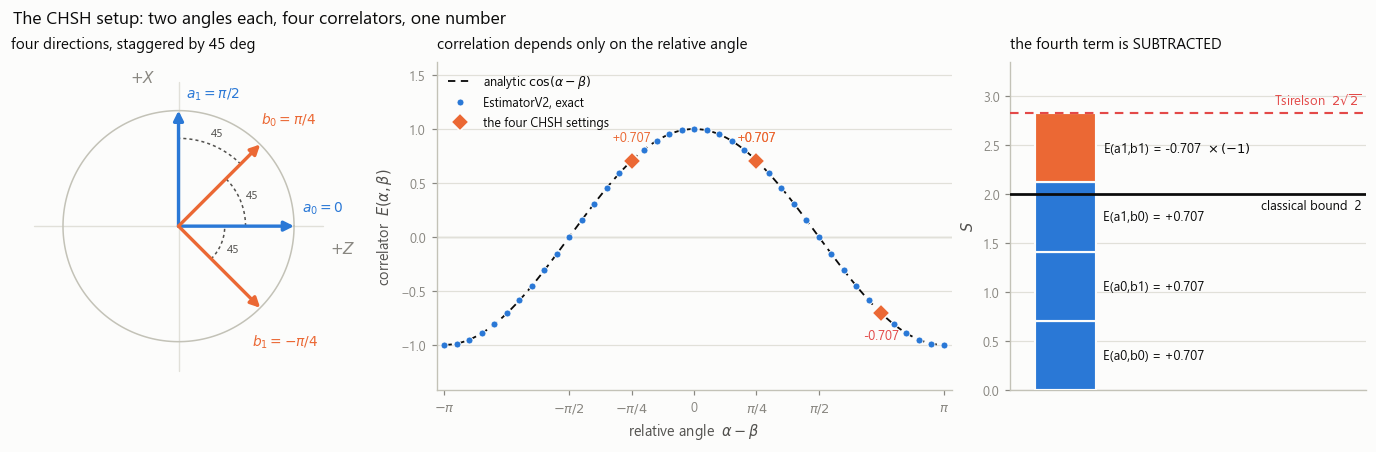

max |EstimatorV2 - cos(delta)| over the sweep: 6.123233995736766e-17


In [4]:
# The middle panel: sweep Bob's angle with Alice fixed at 0, so the relative
# angle IS Bob's angle. One circuit, one pub, an array of observables - Aer runs
# the circuit once and evaluates every observable against the same state.
delta = np.linspace(-np.pi, np.pi, 121)
# A plain list coerces to an ObservablesArray; np.array(..., dtype=object) does
# NOT - numpy iterates each SparsePauliOp into complex numbers and the pub is
# rejected with "Invalid observable type: complex".
sweep_obs = [chsh_term(0.0, -d) for d in delta]
E_sweep = estimator.run([(BELL, sweep_obs)], precision=0.0).result()[0].data.evs

fig = plt.figure(figsize=(12.4, 4.0))
gs = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.45, 1.0])

# ---- panel A: the measurement directions
axA = fig.add_subplot(gs[0, 0])
t = np.linspace(0, 2 * np.pi, 200)
axA.plot(np.cos(t), np.sin(t), color=style.AXIS, lw=1.0, zorder=1)
axA.plot([-1.25, 1.25], [0, 0], color=style.GRID, lw=0.9, zorder=0)
axA.plot([0, 0], [-1.25, 1.25], color=style.GRID, lw=0.9, zorder=0)
# the POSITIVE ends: angles are measured from +Z toward +X, so labelling the
# other ends would quietly invert the whole convention
axA.text(1.42, -0.13, "$+Z$", ha="center", va="top", fontsize=10,
         color=style.MUTED)
axA.text(-0.20, 1.28, "$+X$", ha="right", va="center", fontsize=10,
         color=style.MUTED)

# label offsets are hand-placed: the four directions are only 45 deg apart and
# a uniform radial offset collides with the axis labels.
arrows = [(ALPHA[0], style.BLUE, "$a_0 = 0$", (1.25, 0.16)),
          (ALPHA[1], style.BLUE, r"$a_1 = \pi/2$", (0.30, 1.14)),
          (BETA[0], style.ORANGE, r"$b_0 = \pi/4$", (0.95, 0.92)),
          (BETA[1], style.ORANGE, r"$b_1 = -\pi/4$", (0.92, -1.00))]
for (ang, col, lab, pos) in arrows:
    axA.annotate("", xy=(np.cos(ang), np.sin(ang)), xytext=(0, 0),
                 arrowprops=dict(arrowstyle="-|>", color=col, lw=2.2,
                                 shrinkA=0, shrinkB=0, mutation_scale=13),
                 zorder=4)
    axA.text(pos[0], pos[1], lab, color=col, fontsize=9,
             ha="center", va="center", zorder=5)

# the 45-degree gaps, as arcs at staggered radii so the labels never collide
for (lo, hi), rad in [((-np.pi / 4, 0.0), 0.40), ((0.0, np.pi / 4), 0.58),
                      ((np.pi / 4, np.pi / 2), 0.76)]:
    tt = np.linspace(lo, hi, 40)
    axA.plot(rad * np.cos(tt), rad * np.sin(tt), color=style.INK_2, lw=1.0,
             ls=(0, (2, 2)), zorder=3)
    mid = 0.5 * (lo + hi)
    axA.text((rad + 0.11) * np.cos(mid), (rad + 0.11) * np.sin(mid), "45",
             fontsize=7.5, color=style.INK_2, ha="center", va="center",
             zorder=4,
             bbox=dict(facecolor=style.SURFACE, edgecolor="none", pad=0.6))

axA.set_xlim(-1.45, 1.62)
axA.set_ylim(-1.42, 1.42)
axA.set_aspect("equal")
axA.axis("off")
axA.set_title("four directions, staggered by 45 deg", loc="left", fontsize=10)

# ---- panel B: the correlator
axB = fig.add_subplot(gs[0, 1])
axB.axhline(0, color=style.AXIS, lw=0.9, zorder=1)
axB.plot(delta, np.cos(delta), color=style.INK, lw=1.2, ls=(0, (4, 3)), zorder=3,
         label=r"analytic $\cos(\alpha-\beta)$")
axB.plot(delta[::3], E_sweep[::3], ls="none", marker="o", ms=4.6,
         color=style.BLUE, markeredgecolor=style.SURFACE, markeredgewidth=0.6,
         zorder=4, label="EstimatorV2, exact")
gaps = [ALPHA[i] - BETA[j] for i, j in CHSH_PAIRS]
axB.plot(gaps, exact, ls="none", marker="D", ms=8.0, color=style.ORANGE,
         markeredgecolor=style.SURFACE, markeredgewidth=1.1, zorder=5,
         label="the four CHSH settings")
for (i, j), g, e, s in zip(CHSH_PAIRS, gaps, exact, CHSH_SIGNS):
    axB.annotate(f"{'+' if s > 0 else '-'}{abs(e):.3f}", xy=(g, e),
                 xytext=(0, 13 if s > 0 else -17), textcoords="offset points",
                 ha="center", fontsize=8.5,
                 color=style.ORANGE if s > 0 else style.RED)
axB.set_xticks([-np.pi, -np.pi / 2, -np.pi / 4, 0, np.pi / 4, np.pi / 2, np.pi])
axB.set_xticklabels([r"$-\pi$", r"$-\pi/2$", r"$-\pi/4$", "0", r"$\pi/4$",
                     r"$\pi/2$", r"$\pi$"])
axB.set_xlim(-np.pi - 0.1, np.pi + 0.1)
axB.set_ylim(-1.42, 1.62)
axB.set_xlabel(r"relative angle  $\alpha - \beta$")
axB.set_ylabel(r"correlator  $E(\alpha,\beta)$")
axB.legend(loc="upper left", fontsize=8.2)
axB.set_title("correlation depends only on the relative angle", loc="left",
              fontsize=10)

# ---- panel C: the four terms stacked
axC = fig.add_subplot(gs[0, 2])
contrib = exact * CHSH_SIGNS
bottoms = np.concatenate([[0.0], np.cumsum(contrib)[:-1]])
cols = [style.BLUE, style.BLUE, style.BLUE, style.ORANGE]
for k in range(4):
    axC.bar(0, contrib[k], bottom=bottoms[k], width=0.5, color=cols[k],
            edgecolor=style.SURFACE, linewidth=1.4, zorder=3)
    sign_note = r"$\times\,(-1)$" if CHSH_SIGNS[k] < 0 else ""
    axC.text(0.31, bottoms[k] + contrib[k] / 2,
             f"{names[k]} = {exact[k]:+.3f}  {sign_note}", va="center",
             ha="left", fontsize=8.5, color=style.INK, zorder=6)
axC.axhline(CLASSICAL, color=style.INK, lw=1.8, zorder=5)
axC.text(2.42, CLASSICAL - 0.05, "classical bound  2", fontsize=8.5,
         color=style.INK, va="top", ha="right", zorder=6)
axC.axhline(TSIRELSON, color=style.RED, lw=1.4, ls=(0, (4, 3)), zorder=5)
axC.text(2.42, TSIRELSON + 0.05, r"Tsirelson  $2\sqrt{2}$", fontsize=8.5,
         color=style.RED, va="bottom", ha="right", zorder=6)
axC.set_xlim(-0.45, 2.45)
axC.set_ylim(0, 3.35)
axC.set_xticks([])
axC.set_ylabel("$S$")
axC.set_title("the fourth term is SUBTRACTED", loc="left", fontsize=10)

fig.suptitle("The CHSH setup: two angles each, four correlators, one number",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print("max |EstimatorV2 - cos(delta)| over the sweep:",
      float(np.max(np.abs(E_sweep - np.cos(delta)))))

---

## Part 2 — where $|S| \le 2$ comes from, with no physics in it

This is the part worth reading slowly, because it is the part people assume is
hard and it is not.

**Assume local realism.** Concretely, assume there is some hidden variable
$\lambda$ — anything at all: a shared random seed, a property fixed at the
source, the state of the universe — such that for each run,

$$A_0, A_1, B_0, B_1 \in \{-1, +1\}$$

are all **definite numbers**, determined by $\lambda$. $A_1$ is what Alice *would
have* got had she chosen setting 1, whether or not she did. Bob's values do not
depend on Alice's choice (that is the *locality* part) and Alice's do not depend
on Bob's.

Now look at the combination for a single $\lambda$:

$$A_0B_0 + A_0B_1 + A_1B_0 - A_1B_1
= A_0(B_0 + B_1) + A_1(B_0 - B_1).$$

$B_0$ and $B_1$ are each $\pm1$. So either they are **equal**, in which case
$B_0 - B_1 = 0$ and $B_0 + B_1 = \pm2$; or they are **different**, in which case
$B_0 + B_1 = 0$ and $B_0 - B_1 = \pm2$. Exactly one of the two brackets is zero
and the other is $\pm2$. Multiplying by $A_0$ or $A_1$ (both $\pm1$) cannot change
the magnitude, so for **every** $\lambda$,

$$A_0B_0 + A_0B_1 + A_1B_0 - A_1B_1 = \pm 2.$$

Average over any distribution of $\lambda$ you like, and an average of numbers
each equal to $\pm2$ lies in $[-2, 2]$:

$$\boxed{\;|S| \le 2\;}$$

That is the whole derivation. No Hilbert space, no operators, no Born rule. It is
a statement about *four numbers each equal to $\pm1$* — and it is why a
measurement of $S > 2$ is so violent. It does not falsify a calculation; it
falsifies the assumption that those four numbers all existed.

**Which assumption dies?** The proof used two things: that all four counterfactual
values are simultaneously definite (*realism*), and that Bob's values do not depend
on Alice's setting (*locality*). Bell's theorem kills the conjunction. Choosing
which one to give up is where physicists still disagree, and no experiment settles
it.

## Figure 2 — twenty thousand local models, all of them stuck

Two panels, both attacking the bound from the classical side.

**Left**, the local polytope. Enumerate all $2^4 = 16$ deterministic assignments
of $(A_0, A_1, B_0, B_1)$; each gives exactly $S = \pm2$, and they are the
*vertices* of the set of achievable classical correlations. Every local model
whatsoever is a probabilistic mixture of these sixteen, so its $S$ is a weighted
average of $\pm2$'s. We draw 20,000 random mixtures. The histogram has hard walls.

**Right**, the model a physicist actually reaches for: at the source, the pair is
given a shared random direction $\lambda$, and each side answers
$\mathrm{sign}\big(\cos(\lambda - \text{angle})\big)$ — "the particles agreed in
advance which way to point". This is a perfectly sensible, perfectly local theory,
simulated with real random numbers. Its correlator is a **triangle wave**,
$1 - 2|\Delta|/\pi$: linear in the angle. The quantum cosine is *above* it
everywhere in between. That vertical gap is the whole of Bell's theorem.

S over all 16 deterministic local strategies: [-2  2]
20000 random local models:  min -1.999990  max +1.999945  (bound: 2)
any model above 2? False



shared-direction model at the optimal angles: S = 2.0000 (quantum: 2.8284)


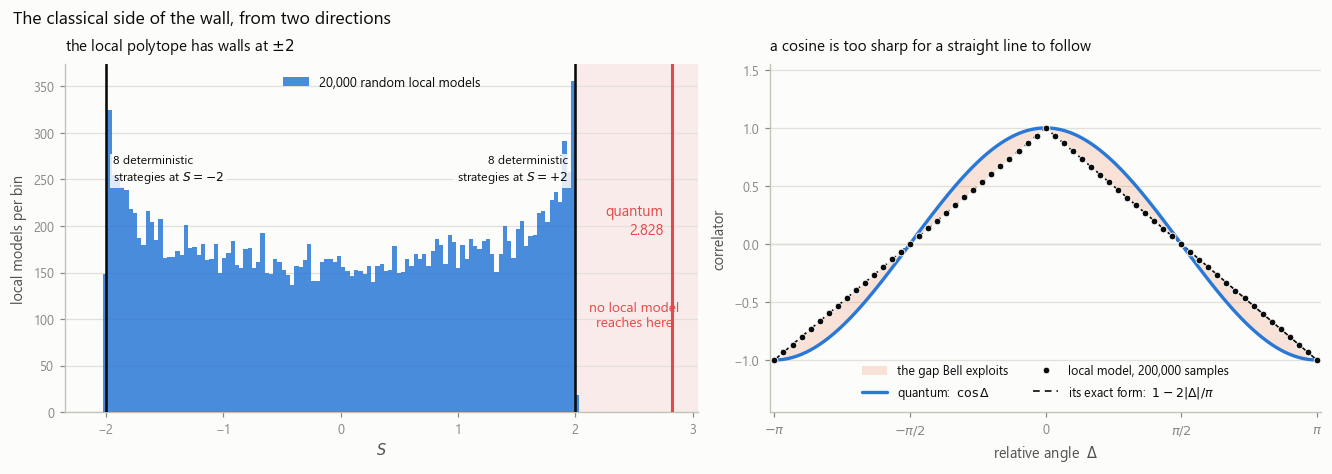

largest deviation of the simulated LHV correlator from 1-2|d|/pi: 0.0034


In [5]:
# ---- the local polytope: 16 deterministic strategies, and mixtures of them
DET = np.array(list(itertools.product([-1, 1], repeat=4)))     # A0, A1, B0, B1
S_DET = (DET[:, 0] * DET[:, 2] + DET[:, 0] * DET[:, 3]
         + DET[:, 1] * DET[:, 2] - DET[:, 1] * DET[:, 3])
print("S over all 16 deterministic local strategies:", np.unique(S_DET))

N_MIX = 20000
# Dirichlet with alpha < 1 puts weight near the vertices, so the walls at +-2
# are actually populated rather than a distant tail.
weights = rng.dirichlet(np.full(16, 0.10), size=N_MIX)
S_mix = weights @ S_DET
print(f"{N_MIX} random local models:  min {S_mix.min():+.6f}  "
      f"max {S_mix.max():+.6f}  (bound: 2)")
print("any model above 2?", bool(np.any(np.abs(S_mix) > 2 + 1e-12)))

# ---- the "shared random direction" hidden-variable model, simulated
N_LHV = 200000
lam = rng.uniform(0, 2 * np.pi, N_LHV)


def lhv_response(angle, lam):
    """Each side answers +-1 from the shared direction alone. Purely local:
    the response depends on THIS side's angle and on lambda, never on the
    other side's angle."""
    return np.sign(np.cos(lam - angle) + 1e-18)


def lhv_correlator(a, b, lam):
    return float(np.mean(lhv_response(a, lam) * lhv_response(b, lam)))


delta_lhv = np.linspace(-np.pi, np.pi, 61)
E_lhv = np.array([lhv_correlator(0.0, -d, lam) for d in delta_lhv])
E_lhv_theory = 1 - 2 * np.abs(delta_lhv) / np.pi

S_lhv = sum(s * lhv_correlator(ALPHA[i], BETA[j], lam)
            for (i, j), s in zip(CHSH_PAIRS, CHSH_SIGNS))
print(f"\nshared-direction model at the optimal angles: S = {S_lhv:.4f} "
      f"(quantum: {S_opt:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2),
                         gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
ax.hist(S_mix, bins=np.linspace(-2.35, 3.05, 150), color=style.BLUE,
        alpha=0.85, zorder=3, label=f"{N_MIX:,} random local models")
for v, cnt in zip(*np.unique(S_DET, return_counts=True)):
    ax.axvline(v, color=style.INK, lw=1.7, zorder=5)
    # inside the axes, not above them: a text at y > 1 collides with the title
    ax.text(v - 0.06 * np.sign(v), 0.74,
            f"{cnt} deterministic\nstrategies at $S = {v:+.0f}$",
            transform=ax.get_xaxis_transform(),
            ha="right" if v > 0 else "left", va="top", fontsize=8,
            color=style.INK, zorder=7,
            bbox=dict(facecolor=style.SURFACE, edgecolor="none", alpha=0.85,
                      pad=2.0))
ax.axvspan(2, 3.05, color=style.RED, alpha=0.09, lw=0, zorder=1)
ax.axvline(TSIRELSON, color=style.RED, lw=2.0, zorder=6)
ax.annotate(f"quantum\n{TSIRELSON:.3f}", xy=(TSIRELSON, 0.55),
            xycoords=("data", "axes fraction"), xytext=(-6, 0),
            textcoords="offset points", ha="right", va="center", fontsize=9.5,
            color=style.RED)
ax.text(2.5, 0.28, "no local model\nreaches here", transform=ax.get_xaxis_transform(),
        ha="center", va="center", fontsize=9, color=style.RED)
ax.set_xlim(-2.35, 3.05)
ax.set_xlabel("$S$")
ax.set_ylabel("local models per bin")
ax.legend(loc="upper center", fontsize=8.5)
ax.set_title("the local polytope has walls at $\\pm 2$", loc="left", fontsize=10)

ax = axes[1]
ax.axhline(0, color=style.AXIS, lw=0.9, zorder=1)
ax.fill_between(delta_lhv, E_lhv_theory, np.cos(delta_lhv),
                where=np.cos(delta_lhv) >= E_lhv_theory, color=style.ORANGE,
                alpha=0.18, lw=0, zorder=2, label="the gap Bell exploits")
ax.fill_between(delta_lhv, E_lhv_theory, np.cos(delta_lhv),
                where=np.cos(delta_lhv) < E_lhv_theory, color=style.ORANGE,
                alpha=0.18, lw=0, zorder=2)
ax.plot(delta, np.cos(delta), color=style.BLUE, lw=2.2, zorder=4,
        label=r"quantum:  $\cos\Delta$")
ax.plot(delta_lhv, E_lhv, ls="none", marker="o", ms=4.4, color=style.INK,
        markeredgecolor=style.SURFACE, markeredgewidth=0.6, zorder=5,
        label=f"local model, {N_LHV:,} samples")
ax.plot(delta_lhv, E_lhv_theory, color=style.INK, lw=1.1, ls=(0, (4, 3)),
        zorder=3, label=r"its exact form:  $1 - 2|\Delta|/\pi$")
ax.set_xticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
ax.set_xticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])
ax.set_xlim(-np.pi - 0.05, np.pi + 0.05)
ax.set_ylim(-1.45, 1.55)
ax.set_xlabel(r"relative angle  $\Delta$")
ax.set_ylabel("correlator")
ax.legend(loc="lower center", fontsize=8.2, ncols=2)
ax.set_title("a cosine is too sharp for a straight line to follow", loc="left",
             fontsize=10)

fig.suptitle("The classical side of the wall, from two directions",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print(f"largest deviation of the simulated LHV correlator from 1-2|d|/pi: "
      f"{np.max(np.abs(E_lhv - E_lhv_theory)):.4f}")

The left panel is the honest version of "classical physics cannot do this". It
is not that nobody has thought of a clever enough local model — it is that the set
of *all* of them is a convex polytope whose vertices we just enumerated, and the
polytope's face is at $S = 2$.

The right panel shows why the cosine wins. Both curves start at $1$ and end at
$-1$; the local one is forced to get there **linearly**, because a $\pm1$ response
function that flips once per turn produces an overlap that falls off in proportion
to the angle. The quantum correlation falls off like $\cos$, which is *flat* at
small angles. CHSH is designed to sample exactly the three places where the cosine
is above the line and the one place it is below, and to add them with signs that
make all four differences push the same way.

Worth noting: the shared-direction model lands on $S = 2$ *exactly* at these
angles — it is an optimal local model, not a strawman. There is nothing left on
the table.

---

## Part 3 — the money shot

Now sweep. Keep the same shape of arrangement but shrink or stretch it with one
knob $\theta$:

$$a_0 = 0, \quad a_1 = 2\theta, \qquad b_0 = \theta, \quad b_1 = -\theta.$$

At $\theta = \pi/4$ this is the optimal configuration from Part 1. The four
relative angles are $-\theta, \theta, \theta, 3\theta$, so

$$S(\theta) = 3\cos\theta - \cos 3\theta = 6\cos\theta - 4\cos^3\theta,$$

using $\cos 3\theta = 4\cos^3\theta - 3\cos\theta$. Two things fall out of the
closed form, and both are visible in the figure:

- $S(0) = 3 - 1 = 2$. The curve **starts exactly on the classical bound** — with
  all four directions collapsed onto one, quantum mechanics is precisely as
  correlated as the best local model and not one part in $10^6$ more.
- $S(\theta) = 2$ again when $2\cos^3\theta - 3\cos\theta + 1 = 0$, i.e.
  $\cos\theta = \tfrac{\sqrt3 - 1}{2}$, $\theta \approx 68.5°$. Between those two
  crossings the curve is above a line that local realism says has nothing above it.

The blue curve below is `EstimatorV2` at `precision=0.0` — an exact expectation
value, no sampling. The orange points are what an *experiment* gets: 4 circuits
per angle, basis rotations applied as real `ry` gates, 8192 shots each, counted
into a $\pm1$ correlator with the error bar computed from the shot record.

### The error bar is not optional

`Estimator` hands you a number. It does **not** hand you the uncertainty on that
number — Aer's `stds` field just echoes back the `precision` you asked for. The
uncertainty is yours to compute, and a CHSH violation quoted without one is not a
claim.

Each correlator is the sample mean of $N$ draws of a $\pm1$ variable, so
$\mathrm{Var}[E] = (1 - E^2)/N$ (A04's binomial variance, rewritten for a $\pm1$
observable). The four settings are measured on **separate** runs, so they are
independent and the variances add:

$$\sigma_S = \sqrt{\sum_{k=1}^{4} \frac{1 - E_k^2}{N}}.$$

At the optimum every $E_k^2 = 1/2$, giving $\sigma_S = \sqrt{2/N}$.

In [6]:
SHOTS = 8192


def measure_circuit(alpha, beta):
    """Bell pair, then rotate each qubit's measurement axis onto Z and read out.

    Hardware only measures Z. To measure A(a) = cos(a) Z + sin(a) X we need a
    unitary U with U^dag Z U = A(a). Ry(phi)^dag Z Ry(phi) = cos(phi) Z
    - sin(phi) X, so the rotation we want is Ry(-a).  (Verified below.)
    """
    qr, cr = QuantumRegister(2, "q"), ClassicalRegister(2, "c")
    qc = QuantumCircuit(qr, cr)
    qc.h(0)
    qc.cx(0, 1)
    qc.ry(-alpha, 0)          # Alice
    qc.ry(-beta, 1)           # Bob
    qc.measure([0, 1], [0, 1])
    return qc


def correlator_from_counts(counts):
    """E = <(+-1) x (+-1)> = P(even parity) - P(odd parity), and its 1-sigma.

    ".c" is the classical register's NAME - the V2 result-access trap from
    CLAUDE.md section 2. measure_all() would have called it "meas".
    """
    n = sum(counts.values())
    e = sum(v * (1 if k.count("1") % 2 == 0 else -1)
            for k, v in counts.items()) / n
    return e, np.sqrt(max(1.0 - e * e, 0.0) / n)


def sampled_chsh(alpha, beta, shots=SHOTS, seed=SEED, noise_model=None):
    """Run the four settings on SamplerV2 and return (S, sigma_S, E, sigma_E)."""
    sampler = backends.sampler(shots=shots, seed=seed, noise_model=noise_model)
    pubs = [measure_circuit(alpha[i], beta[j]) for i, j in CHSH_PAIRS]
    res = sampler.run(pubs).result()
    out = [correlator_from_counts(res[k].data.c.get_counts()) for k in range(4)]
    E = np.array([o[0] for o in out])
    sig = np.array([o[1] for o in out])
    return float(combine(E)), float(np.sqrt(np.sum(sig ** 2))), E, sig


# Sanity: the rotate-then-measure recipe must reproduce the observable exactly.
probe = QuantumCircuit(1)
probe.ry(-0.9, 0)
from qiskit.quantum_info import Operator      # local import: used only here
U = Operator(probe).data
Zm = np.array([[1, 0], [0, -1]], dtype=complex)
Xm = np.array([[0, 1], [1, 0]], dtype=complex)
print("Ry(-a) rotates the measurement axis correctly:",
      np.allclose(U.conj().T @ Zm @ U, np.cos(0.9) * Zm + np.sin(0.9) * Xm))

S_s, sig_s, E_s, _ = sampled_chsh(ALPHA, BETA)
print(f"\nsampled at the optimum, {SHOTS} shots per setting:")
print("  correlators:", np.round(E_s, 4))
print(f"  S = {S_s:.4f} +- {sig_s:.4f}")
print(f"  exact       {S_opt:.4f}")
print(f"  above the classical bound by "
      f"{(S_s - CLASSICAL) / sig_s:.1f} standard deviations")

Ry(-a) rotates the measurement axis correctly: True



sampled at the optimum, 8192 shots per setting:
  correlators: [ 0.7134  0.7102  0.7112 -0.7202]
  S = 2.8550 +- 0.0155
  exact       2.8284
  above the classical bound by 55.2 standard deviations


In [7]:
# ---- the exact curve: one circuit, one pub, 4 x n_theta observables.
N_THETA = 241
theta = np.linspace(0.0, np.pi / 2, N_THETA)


def sweep_angles(th):
    """a0 = 0, a1 = 2*theta;  b0 = theta, b1 = -theta."""
    return np.array([0.0, 2 * th]), np.array([th, -th])


obs_grid = np.empty((N_THETA, 4), dtype=object)
for i, th in enumerate(theta):
    a, b = sweep_angles(th)
    for j, term in enumerate(chsh_observables(a, b)):
        obs_grid[i, j] = term          # elementwise: row assignment would try
                                       # to flatten each op into numbers

evs = estimator.run([(BELL, obs_grid)], precision=0.0).result()[0].data.evs
S_curve = combine(evs)
S_closed = 3 * np.cos(theta) - np.cos(3 * theta)
print("EstimatorV2 sweep matches 3cos(t) - cos(3t):",
      np.allclose(S_curve, S_closed), " max diff",
      float(np.max(np.abs(S_curve - S_closed))))

# ---- the same local model as Figure 2, swept
S_curve_lhv = np.empty(N_THETA)
for i, th in enumerate(theta):
    a, b = sweep_angles(th)
    S_curve_lhv[i] = sum(s * lhv_correlator(a[i2], b[j2], lam)
                         for (i2, j2), s in zip(CHSH_PAIRS, CHSH_SIGNS))

# ---- sampled points with honest error bars, at 13 angles
theta_pts = np.linspace(0.0, np.pi / 2, 13)
S_pts, sig_pts = [], []
for k, th in enumerate(theta_pts):
    a, b = sweep_angles(th)
    s_hat, sig_hat, _, _ = sampled_chsh(a, b, seed=SEED + 100 + k)
    S_pts.append(s_hat)
    sig_pts.append(sig_hat)
S_pts, sig_pts = np.array(S_pts), np.array(sig_pts)

i_peak = int(np.argmax(S_curve))
print(f"\npeak of the exact curve: S = {S_curve[i_peak]:.9f} at theta = "
      f"{theta[i_peak]/np.pi:.4f} pi   (2*sqrt(2) = {TSIRELSON:.9f})")
above = theta[S_curve > CLASSICAL + 1e-9]
print(f"violation window: theta in ({above.min()/np.pi:.4f} pi, "
      f"{above.max()/np.pi:.4f} pi)  ->  "
      f"{np.degrees(above.max()):.1f} deg wide")

EstimatorV2 sweep matches 3cos(t) - cos(3t): True  max diff 8.881784197001252e-16



peak of the exact curve: S = 2.828427125 at theta = 0.2500 pi   (2*sqrt(2) = 2.828427125)
violation window: theta in (0.0021 pi, 0.3792 pi)  ->  68.2 deg wide


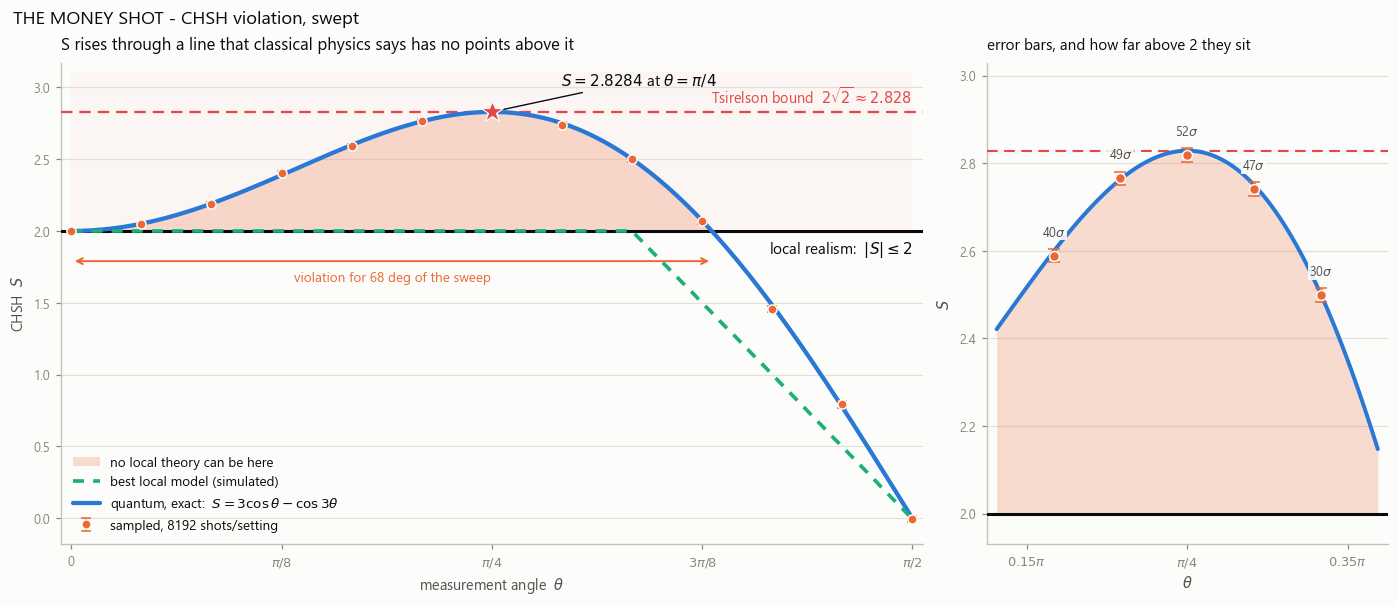

at theta = pi/4:  sampled S = 2.8193 +- 0.0157  = 52.3 sigma above 2
largest sampled S anywhere in the sweep: 2.8193 (Tsirelson 2.8284; a shot-noise fluctuation can exceed it without anything being wrong)


In [8]:
fig = plt.figure(figsize=(12.6, 5.4))
gs = fig.add_gridspec(1, 2, width_ratios=[2.15, 1])

ax = fig.add_subplot(gs[0, 0])

# the shaded impossible region
ax.fill_between(theta, CLASSICAL, S_curve, where=S_curve > CLASSICAL,
                color=style.ORANGE, alpha=0.22, lw=0, zorder=2,
                label="no local theory can be here")
ax.fill_between([theta[0], theta[-1]], CLASSICAL, TSIRELSON + 0.28,
                color=style.RED, alpha=0.035, lw=0, zorder=0)

ax.axhline(TSIRELSON, color=style.RED, lw=1.5, ls=(0, (5, 3)), zorder=4)
ax.text(theta[-1], TSIRELSON + 0.035,
        r"Tsirelson bound  $2\sqrt{2} \approx 2.828$", ha="right", va="bottom",
        fontsize=9.5, color=style.RED)
ax.axhline(CLASSICAL, color=style.INK, lw=2.0, zorder=5)
ax.text(theta[-1], CLASSICAL - 0.055,
        r"local realism:  $|S| \leq 2$", ha="right", va="top", fontsize=10,
        color=style.INK)

# drawn ON TOP of the bound line: the whole point is that it sits exactly on 2.
ax.plot(theta, S_curve_lhv, color=style.AQUA, lw=2.4, ls=(0, (3, 2.5)),
        zorder=8, label="best local model (simulated)")
ax.plot(theta, S_curve, color=style.BLUE, lw=2.8, zorder=7,
        label=r"quantum, exact:  $S = 3\cos\theta - \cos 3\theta$")
ax.errorbar(theta_pts, S_pts, yerr=sig_pts, ls="none", marker="o", ms=6.0,
            color=style.ORANGE, markeredgecolor=style.SURFACE,
            markeredgewidth=1.0, elinewidth=1.6, capsize=3.5, zorder=9,
            label=f"sampled, {SHOTS} shots/setting")

ax.plot([theta[i_peak]], [S_curve[i_peak]], marker="*", ms=15,
        color=style.RED, markeredgecolor=style.SURFACE, markeredgewidth=0.8,
        zorder=10)
grid.annotate(ax, f"$S = {S_curve[i_peak]:.4f}$ at $\\theta = \\pi/4$",
              xy=(theta[i_peak], S_curve[i_peak]),
              xytext=(theta[i_peak] + 0.13, TSIRELSON + 0.22),
              color=style.INK, size=10)
ax.annotate("", xy=(above.max(), 1.79), xytext=(above.min(), 1.79),
            arrowprops=dict(arrowstyle="<->", color=style.ORANGE, lw=1.3,
                            shrinkA=0, shrinkB=0), zorder=6)
ax.text(0.5 * (above.min() + above.max()), 1.72,
        f"violation for {np.degrees(above.max()):.0f} deg of the sweep",
        ha="center", va="top", fontsize=8.8, color=style.ORANGE)

ax.set_xticks(np.array([0, 1 / 8, 1 / 4, 3 / 8, 1 / 2]) * np.pi)
ax.set_xticklabels(["0", r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"])
ax.set_xlim(-0.02, np.pi / 2 + 0.02)
ax.set_ylim(-0.18, TSIRELSON + 0.34)
ax.set_xlabel(r"measurement angle  $\theta$")
ax.set_ylabel("CHSH  $S$")
ax.legend(loc="lower left", fontsize=8.8)
ax.set_title("S rises through a line that classical physics says has no points above it",
             loc="left", fontsize=11)

# ---- zoom on the peak, where the error bars have to be believed
axz = fig.add_subplot(gs[0, 1])
m = (theta > 0.13 * np.pi) & (theta < 0.37 * np.pi)
mp = (theta_pts > 0.13 * np.pi) & (theta_pts < 0.37 * np.pi)
axz.fill_between(theta[m], CLASSICAL, S_curve[m], color=style.ORANGE,
                 alpha=0.22, lw=0, zorder=2)
axz.axhline(TSIRELSON, color=style.RED, lw=1.4, ls=(0, (5, 3)), zorder=4)
axz.axhline(CLASSICAL, color=style.INK, lw=2.0, zorder=5)
axz.plot(theta[m], S_curve[m], color=style.BLUE, lw=2.6, zorder=6)
axz.errorbar(theta_pts[mp], S_pts[mp], yerr=sig_pts[mp], ls="none", marker="o",
             ms=6.5, color=style.ORANGE, markeredgecolor=style.SURFACE,
             markeredgewidth=1.0, elinewidth=1.8, capsize=4.0, zorder=7)
for th, s_hat, sg in zip(theta_pts[mp], S_pts[mp], sig_pts[mp]):
    axz.annotate(f"{(s_hat - CLASSICAL) / sg:.0f}$\\sigma$", xy=(th, s_hat),
                 xytext=(0, 13), textcoords="offset points", ha="center",
                 fontsize=8.2, color=style.INK_2, zorder=8,
                 bbox=dict(facecolor=style.SURFACE, edgecolor="none",
                           alpha=0.9, pad=1.0))
axz.set_xticks(np.array([0.15, 0.25, 0.35]) * np.pi)
axz.set_xticklabels([r"$0.15\pi$", r"$\pi/4$", r"$0.35\pi$"])
axz.set_xlim(0.125 * np.pi, 0.375 * np.pi)
axz.set_ylim(1.93, TSIRELSON + 0.20)
axz.set_xlabel(r"$\theta$")
axz.set_ylabel("$S$")
axz.set_title("error bars, and how far above 2 they sit", loc="left",
              fontsize=10)

fig.suptitle("THE MONEY SHOT - CHSH violation, swept",
             x=0.005, ha="left", fontsize=12)
plt.show()

k = int(np.argmin(np.abs(theta_pts - np.pi / 4)))
print(f"at theta = pi/4:  sampled S = {S_pts[k]:.4f} +- {sig_pts[k]:.4f}  "
      f"= {(S_pts[k]-CLASSICAL)/sig_pts[k]:.1f} sigma above 2")
print(f"largest sampled S anywhere in the sweep: {S_pts.max():.4f} "
      f"(Tsirelson {TSIRELSON:.4f}; a shot-noise fluctuation can exceed it "
      f"without anything being wrong)")

Read the dotted grey line first. That is a *real*, *simulated*, *local* hidden
variable model — the one from Figure 2, with actual random numbers — and it sits
pinned to 2 across the whole sweep. It is not a bad model; it is an optimal one.
Then read the blue curve going over it.

A detail worth not glossing over: a sampled point can come out **above**
$2\sqrt2$ — the $N = 32$ point in the next figure does, at $S \approx 3.19$. That
is not a violation of Tsirelson's bound; it is shot noise on an estimate whose
true value sits exactly *on* it, and an estimator sitting on a ceiling overshoots
it about half the time. If you ever see a raw $S$ above $2\sqrt2$ reported
without comment, that is the reason — and it is why "we measured $S = 2.83$"
means nothing without the number after the $\pm$.

## Figure 4 — how many shots buy the claim

The violation is $2\sqrt2 - 2 \approx 0.828$ and the noise is $\sqrt{2/N}$, so the
significance grows as $0.828\sqrt{N/2} = 0.586\sqrt N$. Setting that to $5$ gives
$N \approx 73$ shots per setting for a $5\sigma$ result on a perfect device.

Seventy-three. On an ideal machine the experiment is nearly free — which tells you
something important: **the difficulty of a real Bell test was never statistical.**
It was systematic. The rest of this notebook, and the honest-limits section, are
about the systematics.

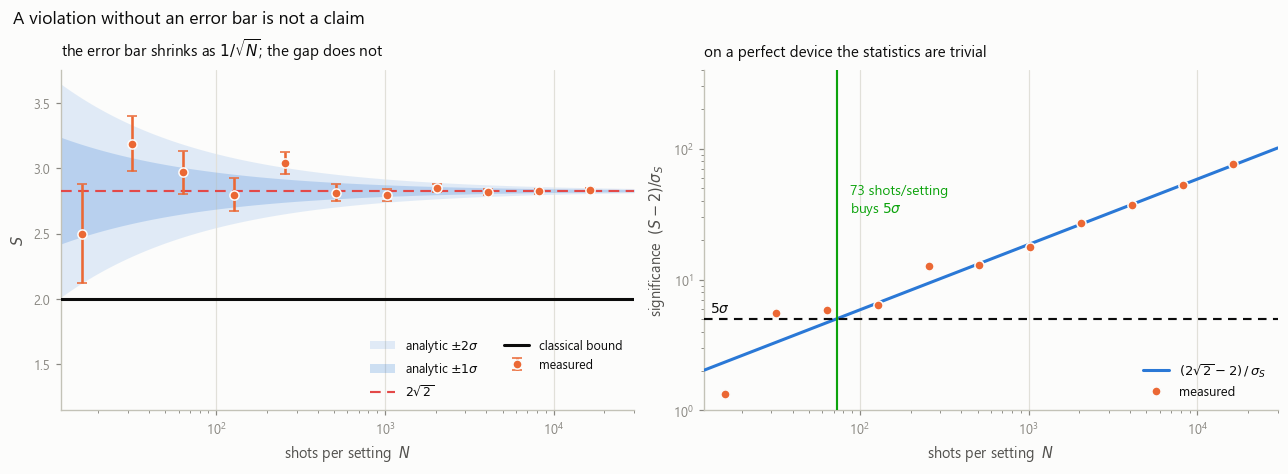

      N         S     sigma   sigma above 2
     16    2.5000    0.3776             1.3
     32    3.1875    0.2128             5.6
     64    2.9688    0.1654             5.9
    128    2.7969    0.1259             6.3
    256    3.0391    0.0812            12.8
    512    2.8125    0.0628            12.9
   1024    2.7949    0.0447            17.8
   2048    2.8457    0.0310            27.2
   4096    2.8179    0.0222            36.9
   8192    2.8218    0.0157            52.5
  16384    2.8368    0.0110            76.0


In [9]:
shot_grid = np.array([16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384])
S_hat, sig_hat = [], []
for k, n in enumerate(shot_grid):
    s_h, g_h, _, _ = sampled_chsh(ALPHA, BETA, shots=int(n), seed=SEED + 500 + k)
    S_hat.append(s_h)
    sig_hat.append(g_h)
S_hat, sig_hat = np.array(S_hat), np.array(sig_hat)

n_dense = np.logspace(np.log10(12), np.log10(3e4), 200)
sig_theory = np.sqrt(2.0 / n_dense)
n_5sigma = 25 * 2.0 / (TSIRELSON - CLASSICAL) ** 2

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.2))

ax = axes[0]
ax.fill_between(n_dense, TSIRELSON - 2 * sig_theory, TSIRELSON + 2 * sig_theory,
                color=style.BLUE, alpha=0.13, lw=0, zorder=1,
                label=r"analytic $\pm 2\sigma$")
ax.fill_between(n_dense, TSIRELSON - sig_theory, TSIRELSON + sig_theory,
                color=style.BLUE, alpha=0.22, lw=0, zorder=2,
                label=r"analytic $\pm 1\sigma$")
ax.axhline(TSIRELSON, color=style.RED, lw=1.4, ls=(0, (5, 3)), zorder=4,
           label=r"$2\sqrt{2}$")
ax.axhline(CLASSICAL, color=style.INK, lw=2.0, zorder=5, label="classical bound")
ax.errorbar(shot_grid, S_hat, yerr=sig_hat, ls="none", marker="o", ms=6.0,
            color=style.ORANGE, markeredgecolor=style.SURFACE,
            markeredgewidth=1.0, elinewidth=1.7, capsize=3.5, zorder=6,
            label="measured")
ax.set_xscale("log")
ax.set_xlim(12, 3e4)
ax.set_ylim(1.15, 3.75)
ax.set_xlabel("shots per setting  $N$")
ax.set_ylabel("$S$")
ax.legend(loc="lower right", fontsize=8.2, ncols=2)
ax.set_title("the error bar shrinks as $1/\\sqrt{N}$; the gap does not",
             loc="left", fontsize=10)
ax.grid(axis="both")

ax = axes[1]
ax.plot(n_dense, (TSIRELSON - CLASSICAL) / sig_theory, color=style.BLUE, lw=2.0,
        zorder=3, label=r"$(2\sqrt{2}-2)\,/\,\sigma_S$")
ax.plot(shot_grid, (S_hat - CLASSICAL) / sig_hat, ls="none", marker="o", ms=6.0,
        color=style.ORANGE, markeredgecolor=style.SURFACE, markeredgewidth=1.0,
        zorder=5, label="measured")
ax.axhline(5, color=style.INK, lw=1.4, ls=(0, (4, 3)), zorder=4)
ax.text(13, 5.6, r"$5\sigma$", fontsize=9, color=style.INK)
ax.axvline(n_5sigma, color=style.GOOD, lw=1.4, zorder=4)
ax.annotate(f"{n_5sigma:.0f} shots/setting\nbuys $5\\sigma$",
            xy=(n_5sigma, 40), xytext=(9, 0), textcoords="offset points",
            fontsize=9, color=style.GOOD, ha="left", va="center")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(12, 3e4)
ax.set_ylim(1, 400)
ax.set_xlabel("shots per setting  $N$")
ax.set_ylabel(r"significance  $(S-2)/\sigma_S$")
ax.legend(loc="lower right", fontsize=8.5)
ax.set_title("on a perfect device the statistics are trivial", loc="left",
             fontsize=10)
ax.grid(axis="both")

fig.suptitle("A violation without an error bar is not a claim",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print(f"{'N':>7}  {'S':>8}  {'sigma':>8}  {'sigma above 2':>14}")
for n, s_h, g_h in zip(shot_grid, S_hat, sig_hat):
    print(f"{n:7d}  {s_h:8.4f}  {g_h:8.4f}  {(s_h-CLASSICAL)/g_h:14.1f}")

---

## Part 4 — and now we kill it

Everything above assumed a perfect Bell state. Turn on noise.

We attach a two-qubit **depolarizing channel** of strength $p$ to the `cx` gate —
the A12 channel, the one that shrinks the Bloch ball toward its centre:

$$\mathcal{E}(\rho) = (1-p)\,\rho + p\,\frac{I}{4}.$$

Because it is the last gate in the preparation, the state we measure is exactly a
**Werner state**

$$\rho_p = (1-p)\,|\Phi^+\rangle\langle\Phi^+| + p\,\frac{I}{4},$$

and since the maximally mixed component has *zero* correlation in every basis, all
four correlators scale by the same factor:

$$S_p(\theta) = (1-p)\,S_0(\theta), \qquad S_p^{\max} = 2\sqrt2\,(1-p).$$

The violation therefore dies at

$$p^\star = 1 - \tfrac{1}{\sqrt2} \approx 0.2929,$$

i.e. once about 29% of your state has become noise, **no choice of angles
recovers a violation**. Not a worse violation — none at all. The state is still
entangled well past that point (a Werner state is entangled for $p < 2/3$), which
is a genuinely important and under-advertised fact: *entanglement is necessary for
a Bell violation but not sufficient.* There is a whole band of states that are
provably entangled and yet admit an explicit local hidden-variable model.

Three panels below: the curve family sinking, the violation region as a map, and
the peak value falling through 2 with sampled points and error bars.

In [10]:
def depolarizing_model(p, two_qubit_only=True):
    """Depolarizing noise on the entangler (and optionally the 1-qubit gates).

    Attaching it only to `cx` makes the output state an exact Werner state, which
    is what lets the checkpoint below assert against a closed form.
    """
    nm = NoiseModel()
    if p > 0:
        nm.add_all_qubit_quantum_error(depolarizing_error(p, 2), ["cx"])
        if not two_qubit_only:
            nm.add_all_qubit_quantum_error(depolarizing_error(p / 2, 1),
                                           ["h", "ry", "u", "rz", "sx", "x"])
    return nm


P_GRID = np.array([0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.2929, 0.35, 0.45])
S_noisy = np.empty((len(P_GRID), N_THETA))
for k, p in enumerate(P_GRID):
    est_p = backends.estimator(seed=SEED + 900 + k,
                               noise_model=depolarizing_model(p) if p > 0 else None)
    ev = est_p.run([(BELL, obs_grid)], precision=0.0).result()[0].data.evs
    S_noisy[k] = combine(ev)

# The Werner prediction, for free: every correlator scales by (1-p).
werner = (1 - P_GRID)[:, None] * S_closed[None, :]
print("noisy sweep matches the Werner prediction (1-p) * S_0(theta):",
      np.allclose(S_noisy, werner, atol=1e-9),
      " max diff", float(np.max(np.abs(S_noisy - werner))))

# Confirm the state really is Werner, straight from the density matrix.
noisy_dm = DensityMatrix(Statevector(BELL))          # p = 0 reference
phi = Statevector(BELL).data
rho_ideal = np.outer(phi, phi.conj())
for p in (0.10, 0.25):
    qc_dm = bell_circuit()
    qc_dm.save_density_matrix(label="rho")
    sim = backends.get_backend(noise_model=depolarizing_model(p),
                               method="density_matrix",
                               seed_simulator=SEED)
    rho = np.asarray(sim.run(qc_dm).result().data()["rho"])
    predicted = (1 - p) * rho_ideal + p * np.eye(4) / 4
    print(f"  p = {p:.2f}: simulated rho == (1-p)|Phi+><Phi+| + p I/4 ?",
          np.allclose(rho, predicted, atol=1e-9))

noisy sweep matches the Werner prediction (1-p) * S_0(theta): True  max diff 2.6645352591003757e-15
  p = 0.10: simulated rho == (1-p)|Phi+><Phi+| + p I/4 ? True
  p = 0.25: simulated rho == (1-p)|Phi+><Phi+| + p I/4 ? True


In [11]:
# A fine grid for the map, and sampled points with error bars for the crossing.
p_fine = np.linspace(0.0, 0.5, 61)
S_map = np.empty((len(p_fine), N_THETA))
for k, p in enumerate(p_fine):
    est_p = backends.estimator(seed=SEED + 1300 + k,
                               noise_model=depolarizing_model(p) if p > 0 else None)
    S_map[k] = combine(est_p.run([(BELL, obs_grid)],
                                 precision=0.0).result()[0].data.evs)

p_pts = np.array([0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45])
S_pk, sig_pk = [], []
for k, p in enumerate(p_pts):
    s_h, g_h, _, _ = sampled_chsh(ALPHA, BETA, seed=SEED + 1700 + k,
                                  noise_model=depolarizing_model(p) if p > 0 else None)
    S_pk.append(s_h)
    sig_pk.append(g_h)
S_pk, sig_pk = np.array(S_pk), np.array(sig_pk)

P_STAR = 1 - 1 / np.sqrt(2)
print(f"violation dies at p* = 1 - 1/sqrt(2) = {P_STAR:.6f}")
for p, s_h, g_h in zip(p_pts, S_pk, sig_pk):
    verdict = "VIOLATION" if s_h - 2 * g_h > CLASSICAL else "no claim"
    print(f"  p = {p:.2f}:  S = {s_h:.4f} +- {g_h:.4f}   "
          f"({(s_h-CLASSICAL)/g_h:+6.1f} sigma)   {verdict}")

violation dies at p* = 1 - 1/sqrt(2) = 0.292893
  p = 0.00:  S = 2.8149 +- 0.0157   ( +51.9 sigma)   VIOLATION
  p = 0.05:  S = 2.6721 +- 0.0164   ( +40.9 sigma)   VIOLATION
  p = 0.10:  S = 2.5283 +- 0.0171   ( +30.9 sigma)   VIOLATION
  p = 0.15:  S = 2.4055 +- 0.0177   ( +23.0 sigma)   VIOLATION
  p = 0.20:  S = 2.2729 +- 0.0182   ( +15.0 sigma)   VIOLATION
  p = 0.25:  S = 2.1003 +- 0.0188   (  +5.3 sigma)   VIOLATION
  p = 0.30:  S = 1.9661 +- 0.0192   (  -1.8 sigma)   no claim
  p = 0.35:  S = 1.8608 +- 0.0196   (  -7.1 sigma)   no claim
  p = 0.40:  S = 1.6716 +- 0.0201   ( -16.4 sigma)   no claim
  p = 0.45:  S = 1.5728 +- 0.0203   ( -21.0 sigma)   no claim


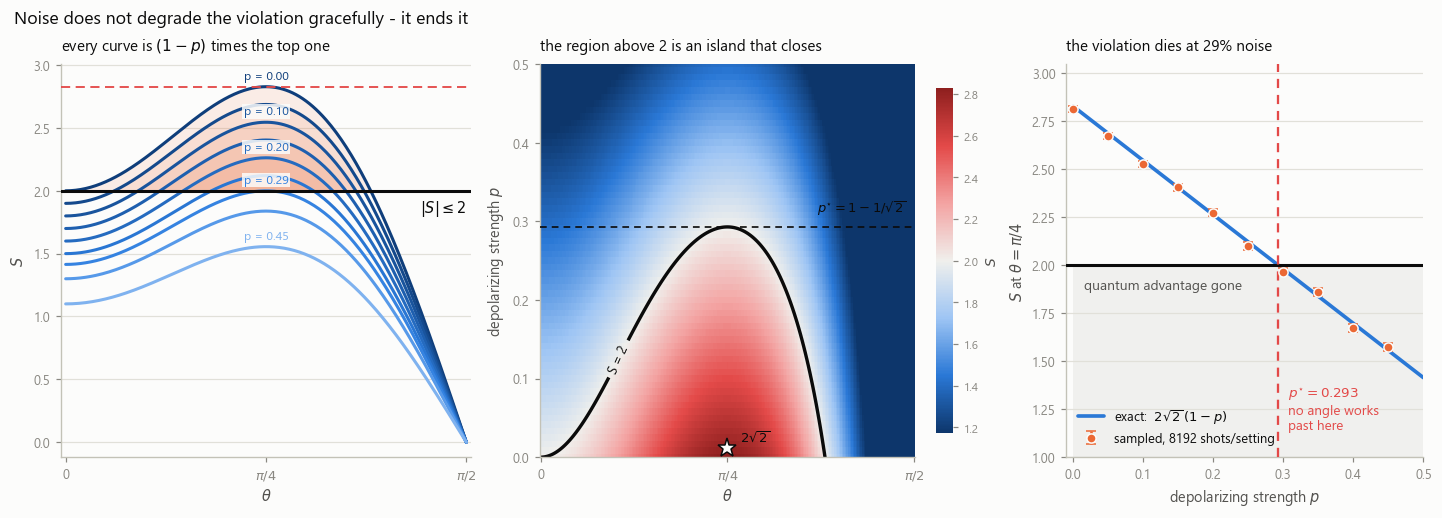

largest p at which the 2-sigma lower bound still clears 2: 0.25


In [12]:
fig = plt.figure(figsize=(13.0, 4.6))
gs = fig.add_gridspec(1, 3, width_ratios=[1.15, 1.05, 1.0])

# ---- panel A: the family of curves sinking
ax = fig.add_subplot(gs[0, 0])
ax.axhline(CLASSICAL, color=style.INK, lw=2.0, zorder=6)
ax.text(np.pi / 2, CLASSICAL - 0.06, r"$|S| \leq 2$", ha="right", va="top",
        fontsize=9.5, color=style.INK)
ax.axhline(TSIRELSON, color=style.RED, lw=1.2, ls=(0, (5, 3)), zorder=5)
shades = plt.get_cmap("quth_seq")(np.linspace(0.92, 0.18, len(P_GRID)))
for k, p in enumerate(P_GRID):
    ax.fill_between(theta, CLASSICAL, S_noisy[k], where=S_noisy[k] > CLASSICAL,
                    color=style.ORANGE, alpha=0.10, lw=0, zorder=2)
    ax.plot(theta, S_noisy[k], color=shades[k], lw=2.0, zorder=4)
    # labelled at the peak, where the curves are flat and maximally separated;
    # they all converge to S = 0 at theta = pi/2, so labelling there is useless.
    if k % 2 == 0 or abs(p - P_STAR) < 0.01:
        ax.annotate(f"p = {p:.2f}", xy=(np.pi / 4, TSIRELSON * (1 - p)),
                    xytext=(0, 3), textcoords="offset points", fontsize=8,
                    color=shades[k], ha="center", va="bottom", zorder=7,
                    bbox=dict(facecolor=style.SURFACE, edgecolor="none",
                              alpha=0.85, pad=0.8))
ax.set_xticks(np.array([0, 1 / 4, 1 / 2]) * np.pi)
ax.set_xticklabels(["0", r"$\pi/4$", r"$\pi/2$"])
ax.set_xlim(-0.02, np.pi / 2 + 0.02)
ax.set_ylim(-0.12, TSIRELSON + 0.18)
ax.set_xlabel(r"$\theta$")
ax.set_ylabel("$S$")
ax.set_title("every curve is $(1-p)$ times the top one", loc="left", fontsize=10)

# ---- panel B: the violation island
ax = fig.add_subplot(gs[0, 1])
# shading="nearest" (flat cells) rather than "gouraud": a smooth gradient is
# ~4x the PNG bytes for no extra information at this cell size.
im = ax.pcolormesh(theta, p_fine, S_map, cmap="quth_div", shading="nearest",
                   vmin=2 * CLASSICAL - TSIRELSON, vmax=TSIRELSON,
                   rasterized=True)
cs = ax.contour(theta, p_fine, S_map, levels=[CLASSICAL], colors=[style.INK],
                linewidths=2.2)
ax.clabel(cs, fmt={CLASSICAL: "S = 2"}, fontsize=8.5, inline=True)
ax.axhline(P_STAR, color=style.INK, lw=1.1, ls=(0, (4, 3)), zorder=4)
ax.text(np.pi / 2 - 0.03, P_STAR + 0.012,
        r"$p^{\star} = 1 - 1/\sqrt{2}$", ha="right", va="bottom", fontsize=8.5,
        color=style.INK)
ax.plot([np.pi / 4], [0.012], marker="*", ms=13, color=style.SURFACE,
        markeredgecolor=style.INK, markeredgewidth=1.0, zorder=6)
ax.annotate(r"$2\sqrt{2}$", xy=(np.pi / 4, 0.012), xytext=(8, 2),
            textcoords="offset points", fontsize=8.5, color=style.INK,
            ha="left", va="bottom", zorder=6)
ax.set_xticks(np.array([0, 1 / 4, 1 / 2]) * np.pi)
ax.set_xticklabels(["0", r"$\pi/4$", r"$\pi/2$"])
ax.set_xlabel(r"$\theta$")
ax.set_ylabel("depolarizing strength $p$")
ax.set_ylim(0, 0.5)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
cb.outline.set_visible(False)
cb.set_label("$S$", fontsize=9)
cb.ax.tick_params(labelsize=7.5)
ax.set_title("the region above 2 is an island that closes", loc="left",
             fontsize=10)

# ---- panel C: the peak falling through the bound
ax = fig.add_subplot(gs[0, 2])
ax.fill_between([0, 0.5], 0.0, CLASSICAL, color=style.MUTED, alpha=0.10, lw=0,
                zorder=1)
ax.plot(p_fine, TSIRELSON * (1 - p_fine), color=style.BLUE, lw=2.4, zorder=4,
        label=r"exact:  $2\sqrt{2}\,(1-p)$")
ax.axhline(CLASSICAL, color=style.INK, lw=2.0, zorder=5)
ax.axvline(P_STAR, color=style.RED, lw=1.5, ls=(0, (4, 3)), zorder=5)
ax.errorbar(p_pts, S_pk, yerr=sig_pk, ls="none", marker="o", ms=6.0,
            color=style.ORANGE, markeredgecolor=style.SURFACE,
            markeredgewidth=1.0, elinewidth=1.7, capsize=3.5, zorder=7,
            label=f"sampled, {SHOTS} shots/setting")
ax.annotate(r"$p^{\star} = 0.293$" + "\nno angle works\npast here",
            xy=(P_STAR, 1.25), xytext=(6, 0), textcoords="offset points",
            fontsize=8.8, color=style.RED, ha="left", va="center")
ax.text(0.015, CLASSICAL - 0.07, "quantum advantage gone", ha="left", va="top",
        fontsize=9, color=style.INK_2)
ax.set_xlim(-0.01, 0.5)
ax.set_ylim(1.0, TSIRELSON + 0.22)
ax.set_xlabel("depolarizing strength $p$")
ax.set_ylabel(r"$S$ at $\theta = \pi/4$")
ax.legend(loc="lower left", fontsize=8.5)
ax.set_title("the violation dies at 29% noise", loc="left", fontsize=10)

fig.suptitle("Noise does not degrade the violation gracefully - it ends it",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

last = p_pts[(S_pk - 2 * np.array(sig_pk)) > CLASSICAL]
print(f"largest p at which the 2-sigma lower bound still clears 2: "
      f"{last.max() if len(last) else float('nan'):.2f}")

The middle panel is the picture to remember. The violation is not a property of
the state alone or the angles alone; it is a *region* in the joint space, and
noise closes it from below like a lid. At $p = 0$ you have $68°$ of angle to play
with. At $p = 0.25$ you have about $30°$. At $p^\star$ the island shrinks to a
single point and then it is gone.

Notice also that the sampled points at $p \gtrsim 0.3$ sit at $S < 2$ with error
bars that comfortably exclude a violation — the experiment does not become
ambiguous, it becomes *negative*. Which is the correct behaviour: a noisy device
does not weakly disprove local realism, it fails to disprove it at all.

---

## Honest limits — read this one

Everything above is a picture of a theory. Here is what it is not.

**A simulator cannot rule out local realism, and this one certainly does not.**
Aer is a classical program. It holds a $4\times4$ density matrix in ordinary RAM
and computes $\mathrm{Tr}(\rho\,A\otimes B)$ with ordinary floating-point
arithmetic. It is, quite literally, a local hidden-variable model — the "hidden
variable" is the array in memory — and it reproduced $S = 2\sqrt2$. There is no
contradiction, because the theorem's locality assumption is about *spacelike
separated measurement choices*, and there is nothing spacelike-separated about two
array indices. This notebook shows you what quantum mechanics **predicts**. Only an
experiment can show you what nature **does**.

**The real experiment needed spacelike separation.** For the locality assumption to
have teeth, Alice's setting choice must be made and her outcome recorded so quickly
that no signal at light speed could carry her choice to Bob's detector before his
outcome is fixed. Miss that and you have the **locality loophole**: a local model
where Bob's apparatus "learns" Alice's setting in time explains the data
completely. Aspect's 1982 experiment switched settings mid-flight; Weihs et al.
(1998) got genuinely spacelike separation with fast random switching over 400 m.

**The detection loophole is the hard one, and it is why fair sampling matters.**
Real detectors miss most of the pairs. If you only compute correlators over the
events where *both* sides fired, you are implicitly assuming the detected subset is
representative — the **fair-sampling assumption**. Drop it and there are explicit
local models that reproduce $S = 4$: let the hidden variable decide, per setting,
whether the particle bothers to trigger the detector, and the surviving subensemble
can be arbitrarily correlated. This is not a hypothetical objection; the model is
easy to write down. Closing it requires *heralded* detection efficiency above a
threshold — about $82.8\%$ for CHSH with a maximally entangled state, and $2/3$
with a cleverly non-maximally entangled one (Eberhard). Photon experiments were
below that for decades. Ion and superconducting experiments have near-perfect
detection but are hard to separate spacelike.

**Both loopholes at once took until 2015.** Hensen et al. (Delft) used
entanglement swapping between NV centres 1.3 km apart — event-ready heralding, so
no fair-sampling assumption, and enough distance for spacelike separation. Giustina
et al. and Shalm et al. followed the same year with high-efficiency photon
detectors. Their statistics were thin (Delft reported $S = 2.42 \pm 0.20$, about
$2\sigma$, on 245 trials) precisely because closing both loopholes at once is
expensive. Compare that with the $50\sigma$ this notebook gets in a second and you
have a fair measure of the distance between simulating physics and doing it. The
2022 Nobel Prize went to Aspect, Clauser and Zeilinger for the programme.

**One loophole is not closable, only narrowed.** The **freedom-of-choice** (or
superdeterminism) loophole: if the setting choices are themselves correlated with
$\lambda$, the derivation fails. You cannot rule this out experimentally, only push
the correlation further back in time — the 2018 "Cosmic Bell" test used photons
from quasars billions of light-years away to choose settings. That constrains the
conspiracy to have been arranged before the quasar light was emitted. It does not
eliminate it.

**Our noise model is optimistic.** We put depolarizing noise on the `cx` gate and
nowhere else. The basis rotations in the sampled runs are noiseless, the readout is
perfect, and the observable in the `EstimatorV2` path is applied as exact algebra
rather than as physical gates. Real readout error alone is a percent or two per
qubit and *directly* attenuates every correlator; add it and $p^\star$ arrives
sooner. Every simplification here moves the answer in the same direction, which is
the direction that flatters quantum mechanics.

**Aer's `EstimatorV2` does not sample.** It computes the exact expectation value
with `save_expectation_value` and, if you ask for a non-zero `precision`, adds
Gaussian noise of that width. That is a *model* of shot noise, not shot noise: it
is symmetric, unbounded, and it will happily return $|E| > 1$. That is why every
error bar in this notebook comes from the `SamplerV2` path — real counts, real
$\pm1$ outcomes, binomial variance — and why the `Estimator` results are only ever
used at `precision=0.0`, where they are exact and carry no uncertainty at all.

**$2\sqrt2$ is not forced by no-signalling.** Tsirelson's bound is a fact about
Hilbert space, not about relativity. You can write down a perfectly consistent
no-signalling theory — the **PR box** — that achieves $S = 4$, the algebraic
maximum, without allowing any faster-than-light communication. Nobody knows a
satisfying first-principles reason why nature stopped at $2\sqrt2$ rather than
going all the way to 4. That is an open question, and one of the more interesting
ones in physics.

**Entangled is not the same as Bell-violating.** Section 4 mentioned it and it
deserves repeating: the Werner state $\rho_p$ is entangled for all $p < 2/3$ but
violates CHSH only for $p < 0.293$. In the band between, the state is provably
non-separable *and* admits an explicit local hidden-variable model for projective
measurements (Werner, 1989). "Entanglement" and "nonlocality" are different
resources, and conflating them is one of the most common errors in popular
accounts.

## Checkpoint

Track B notebooks close by asserting against a from-scratch Track A computation.
Here that means: build the Bell state and the rotated measurement operators in raw
NumPy, little-endian the A06 way, compute $S$ by hand, and demand that Qiskit
agrees.

In [13]:
# ---------------------------------------------------------------- Track A
# Raw NumPy. No qiskit.quantum_info anywhere in this block - the whole point of
# the cross-check is that it is an independent implementation.
I2 = np.eye(2, dtype=complex)
X_A = np.array([[0, 1], [1, 0]], dtype=complex)
Z_A = np.array([[1, 0], [0, -1]], dtype=complex)
H_A = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)


def op_on_A(U, k, n=2):
    """A06's helper: place U on qubit k, little-endian (qubit 0 is the LAST
    Kronecker factor, because it is the RIGHTMOST label character)."""
    out = np.array([[1.0 + 0j]])
    for j in range(n - 1, -1, -1):
        out = np.kron(out, U if j == k else I2)
    return out


# CNOT (control q0, target q1) from its truth table, as in A06/B13.
CNOT_A = np.zeros((4, 4), dtype=complex)
for i in range(4):
    CNOT_A[i ^ ((i & 1) << 1), i] = 1.0

ket00 = np.array([1, 0, 0, 0], dtype=complex)
bell_A = CNOT_A @ op_on_A(H_A, 0) @ ket00


def axis_A(angle):
    """A(angle) = cos(angle) Z + sin(angle) X, a single-qubit +-1 observable."""
    return np.cos(angle) * Z_A + np.sin(angle) * X_A


def term_A(alpha, beta):
    """A(alpha) on qubit 0 (x) B(beta) on qubit 1, little-endian: the qubit-1
    factor comes FIRST in np.kron."""
    return np.kron(axis_A(beta), axis_A(alpha))


def correlator_A(state, alpha, beta):
    return float(np.real(state.conj() @ (term_A(alpha, beta) @ state)))


def chsh_A(state, alpha, beta):
    return sum(s * correlator_A(state, alpha[i], beta[j])
               for (i, j), s in zip(CHSH_PAIRS, CHSH_SIGNS))


def chsh_rho_A(rho, alpha, beta):
    return sum(s * float(np.real(np.trace(rho @ term_A(alpha[i], beta[j]))))
               for (i, j), s in zip(CHSH_PAIRS, CHSH_SIGNS))


# 1. The from-scratch Bell state matches Qiskit's, amplitude for amplitude.
assert np.allclose(bell_A, Statevector(BELL).data)
assert np.allclose(bell_A, np.array([1, 0, 0, 1]) / np.sqrt(2))

# 2. Each measurement axis really is a +-1 observable (Hermitian, A^2 = I).
for ang in (0.0, 0.4, np.pi / 4, np.pi / 2, -np.pi / 3):
    A_ = axis_A(ang)
    assert np.allclose(A_, A_.conj().T)
    assert np.allclose(A_ @ A_, I2)

# 3. THE cross-track assertion: hand-built S == EstimatorV2's S, at the optimum
#    and across the entire swept curve.
S_hand_opt = chsh_A(bell_A, ALPHA, BETA)
assert np.allclose(S_hand_opt, S_opt), (S_hand_opt, S_opt)

S_hand_curve = np.array([chsh_A(bell_A, *sweep_angles(th)) for th in theta])
assert np.allclose(S_hand_curve, S_curve, atol=1e-9)
assert np.allclose(S_hand_curve, S_closed, atol=1e-12)

# 4. The correlator really is cos(alpha - beta), by hand and by Qiskit.
for a_, b_ in [(0.0, 0.3), (1.1, -0.7), (np.pi / 3, np.pi / 3)]:
    assert np.isclose(correlator_A(bell_A, a_, b_), np.cos(a_ - b_))
assert np.allclose(E_sweep, np.cos(delta), atol=1e-9)

# 5. The noiseless optimum is 2*sqrt(2). Stated tolerance: 1e-9 absolute, which
#    is far tighter than float64 accumulation over these operations needs.
assert abs(S_opt - TSIRELSON) < 1e-9
assert abs(float(S_curve.max()) - TSIRELSON) < 1e-9
assert abs(theta[int(np.argmax(S_curve))] - np.pi / 4) < 1e-2

# 6. Tsirelson is a ceiling: nothing anywhere in the exact sweep exceeds it.
assert np.all(S_curve <= TSIRELSON + 1e-9)

# 7. The noisy sweep is exactly the Werner prediction (1-p) * S_0(theta).
assert np.allclose(S_noisy, werner, atol=1e-9)
for k, p in enumerate(P_GRID):
    rho_w = (1 - p) * np.outer(bell_A, bell_A.conj()) + p * np.eye(4) / 4
    assert np.isclose(chsh_rho_A(rho_w, ALPHA, BETA), (1 - p) * TSIRELSON)

# 8. The violation threshold is where the closed form says it is.
assert np.isclose(P_STAR, 1 - 1 / np.sqrt(2))
assert TSIRELSON * (1 - (P_STAR - 1e-6)) > CLASSICAL
assert TSIRELSON * (1 - (P_STAR + 1e-6)) < CLASSICAL

# 9. LOCAL REALISM: no deterministic strategy and no mixture of them exceeds 2.
assert set(np.unique(S_DET)) == {-2, 2}
assert np.all(np.abs(S_mix) <= CLASSICAL + 1e-12)
assert np.all(np.abs(S_curve_lhv) <= CLASSICAL + 5e-3)   # 5e-3 = MC noise

# 10. The sampled violation is real: >10 sigma at the optimum, and consistent
#     with the exact value to within 4 sigma.
assert (S_s - CLASSICAL) / sig_s > 10
assert abs(S_s - S_opt) < 4 * sig_s

# 11. Shot noise falls as 1/sqrt(N) - the measured sigmas track sqrt(2/N).
#     Only from 512 shots up: sigma is estimated FROM the sample, so at small N
#     it inherits the sample's own fluctuation (a run that lands on |E| = 1
#     reports sigma = 0 for that term). That is honest behaviour, not a bug.
big = shot_grid >= 512
assert np.allclose(sig_hat[big], np.sqrt(2.0 / shot_grid[big]), rtol=0.08)

# 12. Little-endian contract, again: "XZ" is X on qubit 1, Z on qubit 0.
xz = SparsePauliOp("XZ").to_matrix()
assert np.allclose(xz, np.kron(X_A, Z_A))
assert np.allclose(xz, op_on_A(X_A, 1) @ op_on_A(Z_A, 0))

print("B19 checkpoint passed.")
print(f"  hand-built S  = {S_hand_opt:.12f}")
print(f"  EstimatorV2 S = {S_opt:.12f}")
print(f"  2*sqrt(2)     = {TSIRELSON:.12f}")

B19 checkpoint passed.
  hand-built S  = 2.828427124746
  EstimatorV2 S = 2.828427124746
  2*sqrt(2)     = 2.828427124746


---

**Next:** [B20 — Interference and Phase Kickback in Qiskit](B20_Interference_Phase_Kickback.ipynb).
CHSH measured a *correlation* between two qubits. B20 goes back to one qubit and
measures a *phase* — the Ramsey interferogram — and watches its fringe contrast
collapse under dephasing in exactly the way the violation collapsed here.